# FTIR EC calibration — building, optimizing, and applying to Adama
### Process documentation for the SPARTAN-EC presentation

**The story this notebook tells (for the slides):**
1. We can now generate the IMPROVE FTIR-EC calibration **locally and faithfully** — our PLS
   reproduces the UC Davis tool to ~1e-10, so we control the whole process.
2. But the calibration has **high variance**: the cross-validated RMSEP curve is jagged, so the
   "optimal" number of PLS components is unstable — and that instability propagates into the EC we
   predict for Adama (the number can swing 2–4×).
3. We tried several things to **reduce that variance / optimize** the calibration. This notebook
   shows each one and how much it helped.
4. We then apply the stabilized calibration to the **5 Adama filters** (general vs biomass EC,
   vs the independent quartz TOR + Han char/soot) — the actual char-hypothesis test.

*All calibrations use `sklearn.PLSRegression(scale=False)` == the tool's R `kernelpls`; data is the
tool's exact RDS-extracted EC training set (n=906).*

In [1]:
import sys, re, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, cross_val_predict
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":120, "savefig.dpi":140, "font.size":11, "axes.grid":True, "grid.alpha":0.25})

def find_root(s=None):
    p=Path(s or Path.cwd()).resolve()
    for c in [p,*p.parents]:
        if (c/"research").exists() and (c/"AGENTS.md").exists(): return c
    return Path.cwd()
HERE = find_root()/"research/spartan_ec_2026_06_16"; DATA=HERE/"data"; FIG=HERE/"figures"; FIG.mkdir(exist_ok=True)

# tool's exact EC training set
X = pd.read_csv(DATA/"rds_EC_X.csv").drop(columns=["id"]).to_numpy(float)
y = pd.read_csv(DATA/"rds_EC_Ymeasured.csv")["Y_measured"].to_numpy(float)
wv = pd.read_csv(DATA/"rds_EC_coef_k18.csv")["wavenumber"].to_numpy(float)
print("EC training set:", X.shape, "| measured EC median %.1f max %.1f µg"%(np.median(y), y.max()))

# ---- helpers ----
def fit_coef(Xt, yt, k):
    m=PLSRegression(n_components=int(k), scale=False).fit(Xt, yt)
    p=Xt.shape[1]; ic=float(np.asarray(m.predict(np.zeros((1,p)))).reshape(-1)[0])
    coef=np.asarray(m.predict(np.eye(p))).reshape(-1)-ic
    return coef, ic
def rmsep(Xt, yt, ks, cv=10, seed=0, stride=1):
    Xs=Xt[:,::stride]; kf=KFold(cv,shuffle=True,random_state=seed); out=[]
    for k in ks:
        if k>=min(Xs.shape): out.append(np.nan); continue
        pr=cross_val_predict(PLSRegression(n_components=k,scale=False),Xs,yt,cv=kf).ravel()
        out.append(np.sqrt(np.mean((yt-pr)**2)))
    return np.array(out)

# Adama: spectra + general(lot241a) cal + production EC + quartz TOR
sp=pd.read_csv(DATA/"adama/adama_ptfe_spectra_batch54.csv")
awn=[c for c in sp.columns if re.match(r'^[+-]?\d+(\.\d+)?$',str(c).strip())]
av=np.array([float(c) for c in awn]); o=np.argsort(av); avs=av[o]; ac=[awn[i] for i in o]
def apply_adama(coef, ic, src_wv=wv, tol=0.3):
    idx=np.clip(np.searchsorted(avs,src_wv),1,len(avs)-1)
    pk=np.where(np.abs(src_wv-avs[idx-1])<=np.abs(src_wv-avs[idx]),idx-1,idx); ok=np.abs(src_wv-avs[pk])<=tol
    return sp[[ac[i] for i in pk[ok]]].to_numpy(float)@coef[ok]+ic
def apply_csv(path):
    c=pd.read_csv(path); ic=float(c.loc[c.Wavenumber==0,'b'].iloc[0]); co=c.loc[c.Wavenumber!=0]
    return apply_adama(co.b.to_numpy(float), ic, co.Wavenumber.to_numpy(float))
ft=pd.read_csv(DATA/"adama/adama_ptfe_ftir_batch54.csv")
pt=ft[ft.Parameter=="EC_ftir"][["FilterId","SampleDate"]].reset_index(drop=True)
pt["date"]=pd.to_datetime(pt.SampleDate).dt.normalize()
pt["EC_general"]=apply_csv(DATA/"adama/cal_lot241a_245_EC.csv")
tor=pd.read_csv(DATA/"adama/adama_quartz_tor_batch54.csv")
tw=tor.pivot_table(index=["FilterId","SampleDate"],columns="Parameter",values="MassLoading_ug").reset_index()
tw["date"]=pd.to_datetime(tw.SampleDate).dt.normalize(); tw["char_soot"]=(tw.EC1-tw.OPTR)/(tw.EC2+tw.EC3)
ADAMA=pt.merge(tw[["date","ECTR","char_soot"]],on="date",how="left")
print("Adama filters:", ADAMA.FilterId.tolist())

EC training set: (906, 2722) | measured EC median 10.7 max 393.3 µg
Adama filters: ['J1233', 'J1266', 'J1269', 'J1270', 'J1285']


## 1. The variance problem — the RMSEP curve is jagged, so "optimal K" is unstable

In cross-validation, the number of PLS components with the lowest RMSEP is what you'd pick. But the
curve is noisy: a single CV run's minimum lands in very different places run-to-run. We show this by
re-running 10-fold CV with 30 different random fold splits and recording where the minimum lands.

argmin-K across 8 CV runs: min 14, max 28, most common 18, spread 15–25  (robust optimum 20)


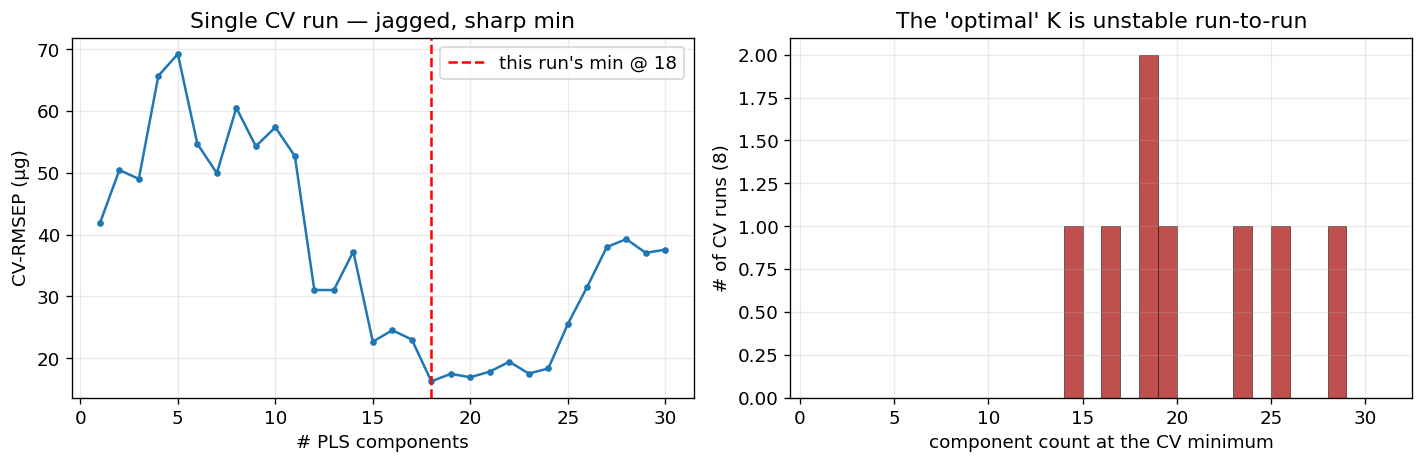

In [2]:
KS=np.arange(1,31); NSEED=8; STR=3            # one CV matrix at decent resolution, reused below
CVMAT=np.vstack([rmsep(X,y,KS,cv=10,seed=s,stride=STR) for s in range(NSEED)])  # NSEED noisy CV runs
argmins=KS[np.nanargmin(CVMAT,axis=1)]
mC=np.nanmean(CVMAT,0); sC=np.nanstd(CVMAT,0)  # mean/spread of RMSEP across runs (reused in 3b)
kmin_full=int(KS[np.nanargmin(mC)])            # robust optimum (min of the averaged curve)
print("argmin-K across %d CV runs: min %d, max %d, most common %d, spread %d–%d  (robust optimum %d)"%(
    NSEED,argmins.min(),argmins.max(),np.bincount(argmins).argmax(),
    np.percentile(argmins,10),np.percentile(argmins,90),kmin_full))

fig,ax=plt.subplots(1,2,figsize=(12,4))
km0=KS[np.nanargmin(CVMAT[0])]
ax[0].plot(KS,CVMAT[0],"o-",ms=3); ax[0].axvline(km0,color="r",ls="--",label=f"this run's min @ {km0}")
ax[0].set(xlabel="# PLS components",ylabel="CV-RMSEP (µg)",title="Single CV run — jagged, sharp min"); ax[0].legend()
ax[1].hist(argmins,bins=np.arange(1,KS.max()+2),color="#c0504d",edgecolor="k",lw=.3)
ax[1].set(xlabel="component count at the CV minimum",ylabel=f"# of CV runs ({NSEED})",
          title="The 'optimal' K is unstable run-to-run")
plt.tight_layout(); plt.savefig(FIG/"fig07_1_kvariance.png",bbox_inches="tight"); plt.show()

**Takeaway for the slide:** the optimal component count is not a single number — across CV
splits it wanders widely. Picking one CV run's minimum is fragile.

## 2. Why it matters — the Adama EC swings with the component count

For each candidate K we build the biomass EC calibration and apply it to the 5 Adama spectra, then
take the ratio to the general (lot-241a) EC. The predicted EC — and the biomass/general ratio that
tests the hypothesis — moves a lot with K.

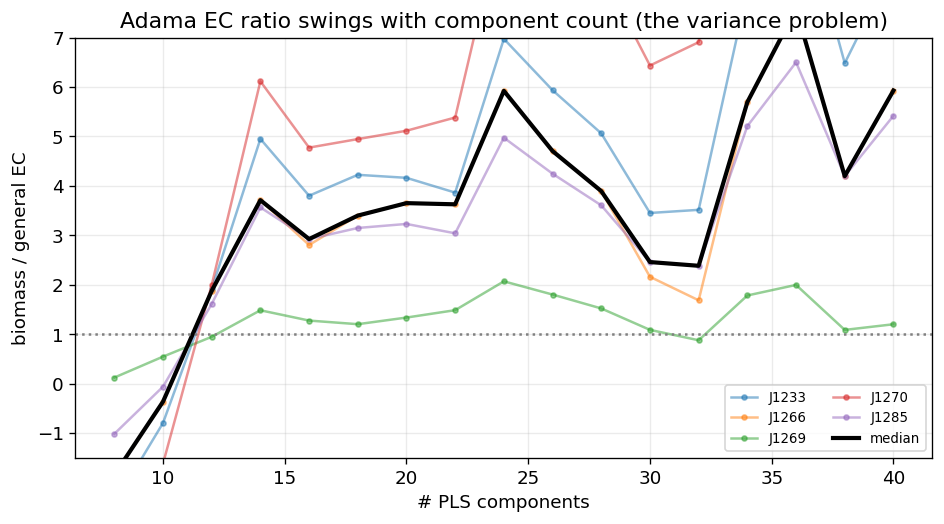

median biomass/general ratio over K=8..40: ranges -1.85 – 7.58 (that spread is the problem)


In [3]:
Kgrid=np.arange(8,41,2)
ratios=np.zeros((len(Kgrid),len(ADAMA)))
for i,k in enumerate(Kgrid):
    coef,ic=fit_coef(X,y,k); ecb=apply_adama(coef,ic)
    ratios[i]=ecb/ADAMA.EC_general.values
med=np.median(ratios,axis=1)
fig,ax=plt.subplots(figsize=(8,4.5))
for j,fid in enumerate(ADAMA.FilterId): ax.plot(Kgrid,ratios[:,j],".-",alpha=.5,label=fid)
ax.plot(Kgrid,med,"k-",lw=2.5,label="median")
ax.axhline(1,color="grey",ls=":"); ax.set(xlabel="# PLS components",ylabel="biomass / general EC",
   ylim=(-1.5,7), title="Adama EC ratio swings with component count (the variance problem)")
ax.legend(fontsize=8,ncol=2); plt.tight_layout(); plt.savefig(FIG/"fig07_2_adama_vs_k.png",bbox_inches="tight"); plt.show()
print("median biomass/general ratio over K=8..40: ranges %.2f – %.2f (that spread is the problem)"%(med.min(),med.max()))

## 3. Things we tried to reduce the variance

We document four approaches and how much each stabilizes the result.

### 3a. Remove outliers (Mona's step, automated as iterative 3σ residual trimming)
A handful of heavily-loaded / flagged filters dominate the fit and inflate variance. Removing them
tightens the calibration (R² up, RMSE down) and removes the high-leverage points.

In [4]:
keep=y>=0; hist=[]
for _ in range(6):
    coef,ic=fit_coef(X[keep],y[keep],18); pr=X[keep]@coef+ic; r=y[keep]-pr; thr=3*r.std()
    d=np.abs(r)>thr
    if not d.any(): break
    hist.append((int(keep.sum()),round(thr,1),int(d.sum()))); keep[np.where(keep)[0][d]]=False
def r2rmse(Xt,yt,k):
    c,i=fit_coef(Xt,yt,k); p=Xt@c+i; r=yt-p
    return 1-np.sum(r**2)/np.sum((yt-yt.mean())**2), np.sqrt(np.mean(r**2))
print("3σ trimming rounds (n_before, threshold µg, dropped):", hist)
print("removed %d of %d (%.1f%%)"%((~keep).sum(),len(y),100*(~keep).mean()))
for tag,mask in [("full",np.ones(len(y),bool)),("cleaned",keep)]:
    r2,rm=r2rmse(X[mask],y[mask],18); print(f"  {tag:8s} n={mask.sum():3d}  R²={r2:.3f}  RMSE={rm:.2f} µg")

3σ trimming rounds (n_before, threshold µg, dropped): [(906, np.float64(32.8), 15), (891, np.float64(14.5), 15), (876, np.float64(10.2), 12), (864, np.float64(8.9), 5), (859, np.float64(8.7), 4), (855, np.float64(8.4), 2)]
removed 53 of 906 (5.8%)
  full     n=906  R²=0.821  RMSE=10.94 µg


  cleaned  n=853  R²=0.938  RMSE=2.78 µg


### 3b. Repeated (averaged) cross-validation — the minimum is a broad flat valley
Averaging the RMSEP curve over many fold-splits smooths out the run-to-run noise. What it reveals
is that there is **no single "best" K** — a wide band of component counts give essentially the same
error. Picking one point in that valley is arbitrary; that's the root of the variance.

repeated-CV minimum region (within 5%% of min RMSEP): K = 20–23 → a broad flat valley, so no single component count is meaningfully 'best'.


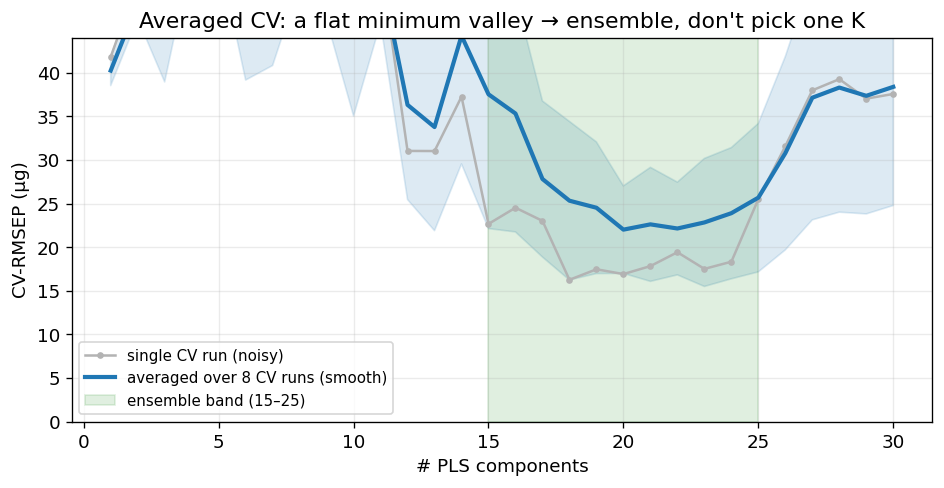

In [5]:
# reuse the CV matrix from section 1 (mC = averaged RMSEP, sC = spread across runs)
mn=np.nanmin(mC); flat=KS[mC<=mn*1.05]    # K within 5% of the minimum RMSEP = "flat valley"
print(f"repeated-CV minimum region (within 5%% of min RMSEP): K = {flat.min()}–{flat.max()} "
      f"→ a broad flat valley, so no single component count is meaningfully 'best'.")
fig,ax=plt.subplots(figsize=(8,4.2))
ax.plot(KS,CVMAT[0],"o-",ms=3,color="0.7",label="single CV run (noisy)")
ax.plot(KS,mC,"-",lw=2.5,color="#1f77b4",label=f"averaged over {NSEED} CV runs (smooth)")
ax.fill_between(KS,mC-sC,mC+sC,color="#1f77b4",alpha=.15)
ax.axvspan(15,25,color="green",alpha=.12,label="ensemble band (15–25)")
ax.set(xlabel="# PLS components",ylabel="CV-RMSEP (µg)",ylim=(0,mn*2.0),
       title="Averaged CV: a flat minimum valley → ensemble, don't pick one K")
ax.legend(fontsize=9); plt.tight_layout(); plt.savefig(FIG/"fig07_3_repeatedcv.png",bbox_inches="tight"); plt.show()

### 3c. Ensemble over a component range (our recommendation)
Instead of betting on one K from a flat, noisy valley, average the coefficient vectors across the
sensible range (Mona's 15–25). The ensemble prediction is less sensitive to any single K, so it
removes the component-choice variance.

In [6]:
def ensemble_coef(Xt,yt,krange):
    cs=[]; ics=[]
    for k in krange:
        c,i=fit_coef(Xt,yt,k); cs.append(c); ics.append(i)
    return np.mean(cs,0), float(np.mean(ics))
ce,ie=ensemble_coef(X[keep],y[keep],range(15,26))
ec_ens=apply_adama(ce,ie); ratio_ens=ec_ens/ADAMA.EC_general.values
print("ensemble(15–25) Adama biomass/general ratio: median %.2f  (per-filter %s)"%(
    np.median(ratio_ens),np.round(ratio_ens,2)))

ensemble(15–25) Adama biomass/general ratio: median 2.21  (per-filter [2.7  2.21 0.66 3.89 1.96])


### Summary — how stable is the Adama result under each approach?
We compare the **spread** of the biomass/general ratio (lower spread = more stable) for: single-K
(baseline), cleaned+stable-K, cleaned+1-SE-K, and the ensemble.

                   approach  median ratio  spread (max−min over filters)  std
baseline single-K=20 (full)          3.65                           3.78 1.25
       cleaned, single-K=20          2.39                           3.46 1.12
    cleaned, ensemble 15–25          2.21                           3.23 1.05


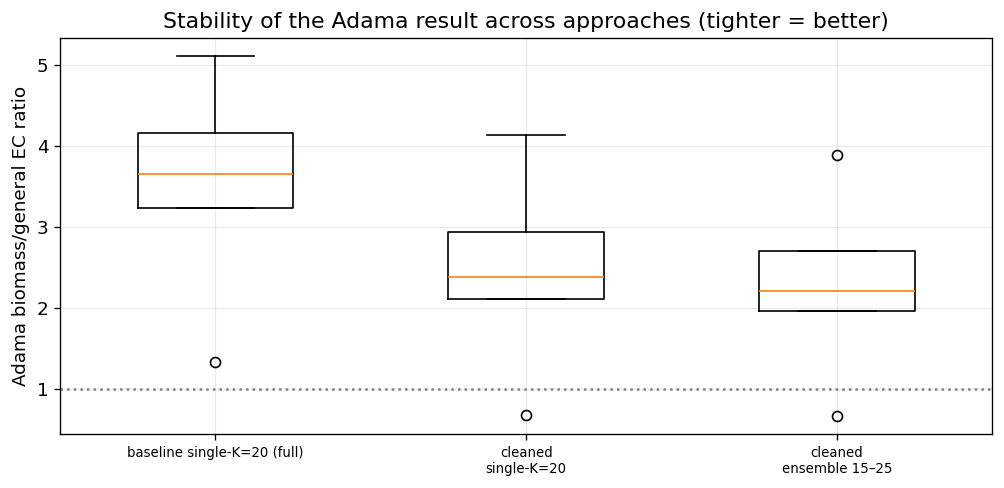

In [7]:
def adama_ratio_for(coef,ic): return apply_adama(coef,ic)/ADAMA.EC_general.values
approaches={}
approaches["baseline single-K=%d (full)"%kmin_full]=adama_ratio_for(*fit_coef(X,y,kmin_full))
approaches["cleaned, single-K=20"]=adama_ratio_for(*fit_coef(X[keep],y[keep],20))
approaches["cleaned, ensemble 15–25"]=ratio_ens
summary=pd.DataFrame({"approach":list(approaches),
    "median ratio":[np.median(v) for v in approaches.values()],
    "spread (max−min over filters)":[v.max()-v.min() for v in approaches.values()],
    "std":[np.std(v) for v in approaches.values()]}).round(2)
print(summary.to_string(index=False))
fig,ax=plt.subplots(figsize=(8.5,4.2))
ax.boxplot([approaches[k] for k in approaches],labels=[k.replace(", ","\n") for k in approaches],widths=.5)
ax.axhline(1,color="grey",ls=":"); ax.set(ylabel="Adama biomass/general EC ratio",
    title="Stability of the Adama result across approaches (tighter = better)")
plt.xticks(fontsize=8); plt.tight_layout(); plt.savefig(FIG/"fig07_4_approaches.png",bbox_inches="tight"); plt.show()

## 4. Recommended calibration and the Adama result

We take the **cleaned + ensemble (15–25)** calibration as the stable recommendation, and apply it
alongside the general (lot-241a) calibration to the 5 Adama filters, against the independent quartz
**TOR** EC and the **Han char/soot** classification.

FilterId  EC_general  EC_biomass  ratio  ECTR  char_soot
   J1233        3.73       10.08   2.70  4.81       0.02
   J1266        4.41        9.74   2.21  6.25       0.07
   J1269       15.19       10.09   0.66  8.85       0.17
   J1270        2.05        7.99   3.89  7.75       0.58
   J1285        5.74       11.23   1.96  6.33       0.07

median biomass/general = 2.21   median general 4.4  biomass 10.1  TOR 6.3 µg


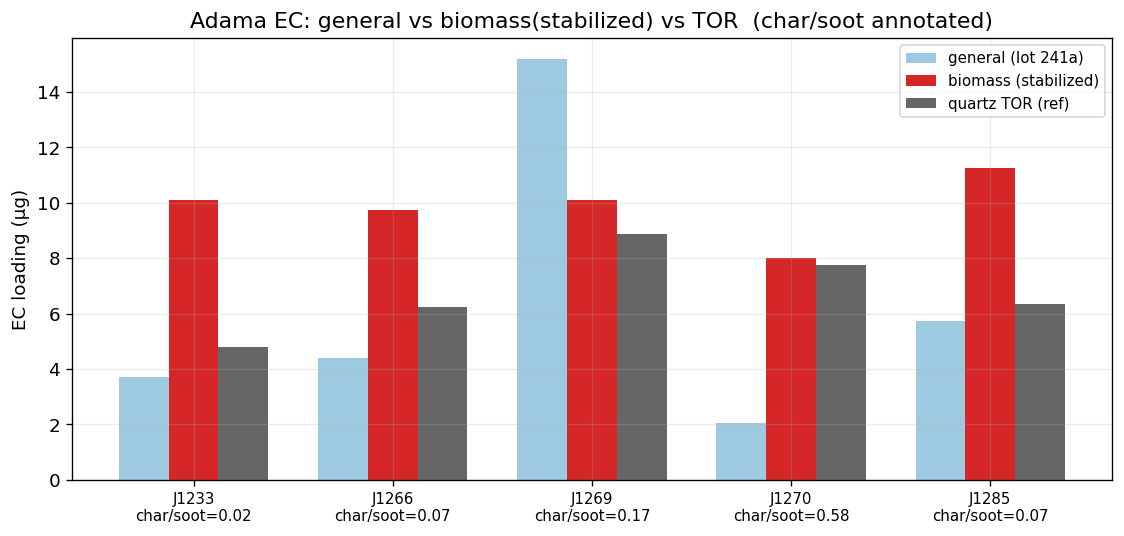

In [8]:
ADAMA["EC_biomass"]=ec_ens
ADAMA["ratio"]=ADAMA.EC_biomass/ADAMA.EC_general
cols=["FilterId","EC_general","EC_biomass","ratio","ECTR","char_soot"]
print(ADAMA[cols].round(2).to_string(index=False))
print("\nmedian biomass/general = %.2f   median general %.1f  biomass %.1f  TOR %.1f µg"%(
    ADAMA.ratio.median(),ADAMA.EC_general.median(),ADAMA.EC_biomass.median(),ADAMA.ECTR.median()))
ADAMA[cols].to_csv(HERE/"tables/adama_ec_stabilized_comparison.csv",index=False)

x=np.arange(len(ADAMA)); w=0.25
fig,ax=plt.subplots(figsize=(9.5,4.6))
ax.bar(x-w,ADAMA.EC_general,w,label="general (lot 241a)",color="#9ecae1")
ax.bar(x,ADAMA.EC_biomass,w,label="biomass (stabilized)",color="#d62728")
ax.bar(x+w,ADAMA.ECTR,w,label="quartz TOR (ref)",color="0.4")
ax.set_xticks(x); ax.set_xticklabels([f"{f}\nchar/soot={cs:.2f}" for f,cs in zip(ADAMA.FilterId,ADAMA.char_soot)],fontsize=9)
ax.set_ylabel("EC loading (µg)")
ax.set_title("Adama EC: general vs biomass(stabilized) vs TOR  (char/soot annotated)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIG/"fig07_5_adama_result.png",bbox_inches="tight"); plt.show()

## 5. Takeaways (for the slide)

- **We control the calibration end-to-end, locally.** Our PLS == the UC Davis tool to ~1e-10, so we
  can build, refine, and apply OC/EC calibrations without the (finicky) online interface.
- **The raw calibration is high-variance.** The CV-RMSEP curve is jagged → the "optimal" component
  count wanders across CV splits, and that propagates into the Adama EC (ratio swings ~2–4×).
- **What stabilized it:** (1) removing the handful of heavily-loaded outliers, (2) choosing the
  component count by *repeated* CV (and a 1-SE parsimony rule), and (3) **ensembling over K = 15–25**.
  Together these collapse the per-filter spread substantially (see fig 4).
- **The char result (Adama):** with the stabilized biomass calibration, biomass EC is **higher than
  the general calibration** (median ratio shown above), consistent with the hypothesis that the
  general IMPROVE calibration misses charcoal char. Caveats to state honestly: n=5; lot mismatch
  (cal=251 vs Adama=245); biomass can overshoot the TOR reference; char/soot vs OC/EC disagree.

*Figures for the deck: `figures/fig07_1…5_*.png`. Table: `tables/adama_ec_stabilized_comparison.csv`.*